# Data analysis in Astronomy

# Homework 1

Due Sep 23 11:59 pm  

* Please submit your homework through NTU cool 
* Please write your answers in English

Answer these questions in the jupyter notebook and output as a PDF file which includes the code you wrote. 
### Please make sure that you can export your file as a pdf file before the deadline. [You might encounter some technical issues]

## 1. Use SDSS datasets, find spectra of  a star, a quasar, and a galaxy and plot them

(15%)

a). Download of the spectra of these sources and plot the spectra with your own code. [10%]
(hint: you would need to learn the structure of the SDSS spectra fit file.)

b). Observe and describe the main differences between the spectra of the star, quasar and galaxy. [5%]



b).

Stars have absorption lines in their spectra, such as H alpha, H beta , and D 1 .  These lines are caused by the elements in their atmospheres absorbing specific wavelengths of light.

Galaxies display both absorption and emission lines. The emission lines, such as [OII], [OIII], and HeII, originate from ionized gas within the galaxy. The absorb lines is from the stars, especially the light absorbed by old stars.

QSOs show the strong emission lines like Mg. Since quasars are usually distant and have high redshifts, they often show significant Ly- alpha emission. This feature can help us identify high redshift quasars.

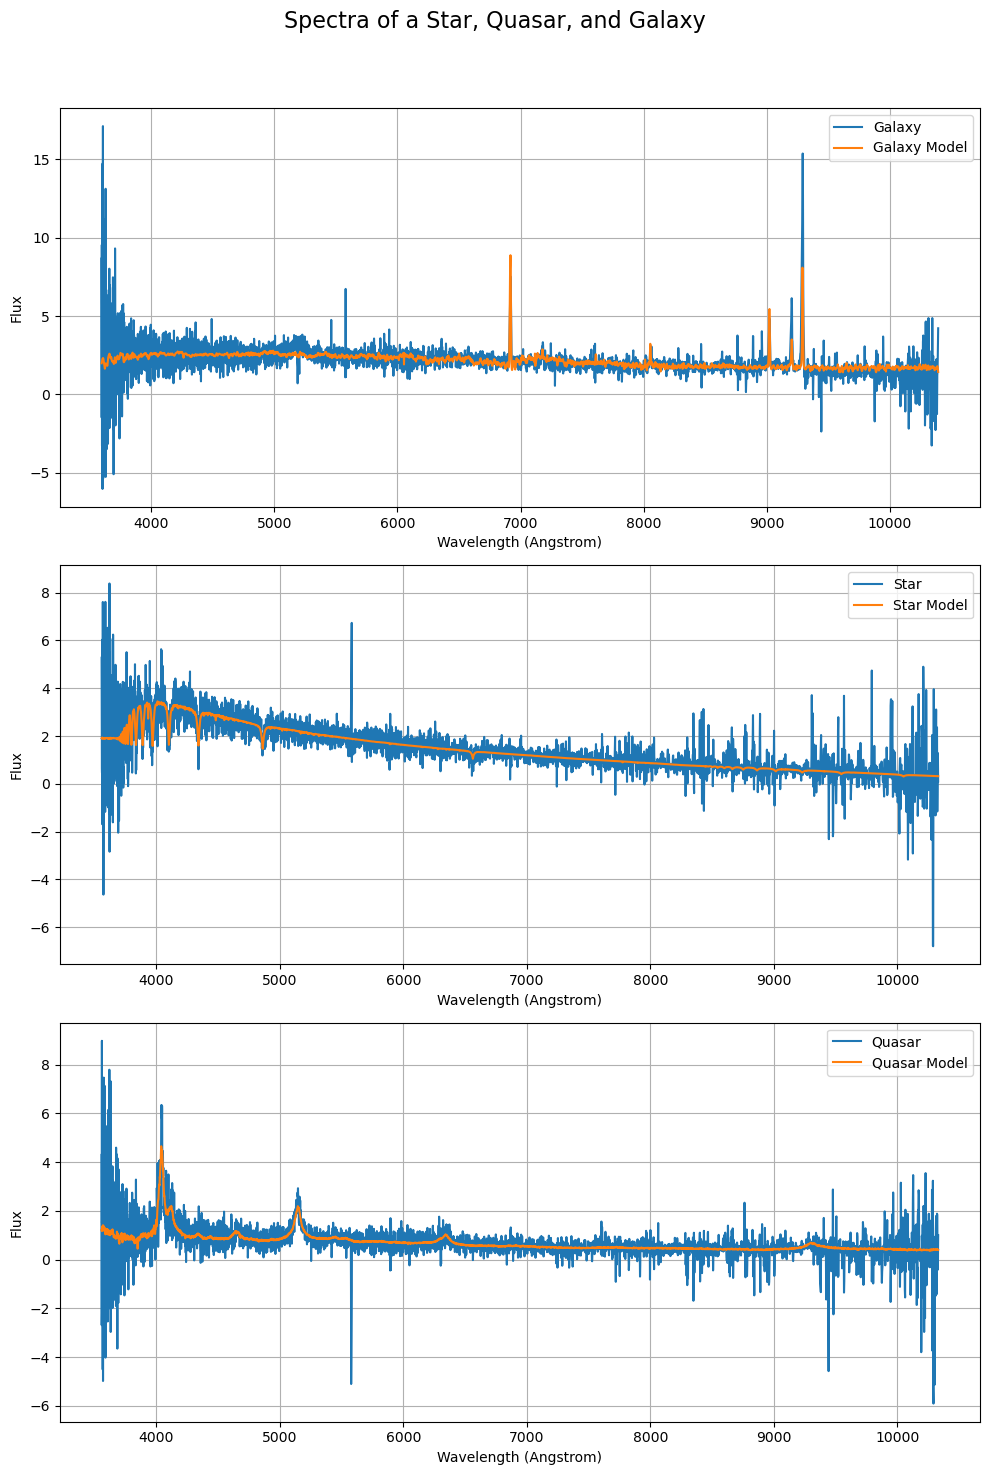

In [61]:
from astropy.io import fits
import matplotlib.pyplot as plt
"""
These code used Githhub copilot to help me write the code. 
"""


# Function to download and plot SDSS spectrum
def download_and_plot_spectrum(ax, path, label):
    hdul = fits.open(path)
    
    flux = hdul[1].data['flux']
    model = hdul[1].data['model']
    loglam = hdul[1].data['loglam']
    wavelength = 10**loglam  # Convert log(wavelength) to wavelength

    # Plot the spectrum 
    ax.plot(wavelength, flux, label=label)
    ax.plot(wavelength, model, label=f'{label} Model')
    ax.set_xlabel('Wavelength (Angstrom)')
    ax.set_ylabel('Flux')
    ax.legend()
    ax.grid(True)

# File paths 
galaxy_path = "HW1/Optical_Spectrum_galaxy.fits"
star_path = "HW1/Optical_Spectrum_Star.fits"
QSO_path = "HW1/Optical_Spectrum_QSO.fits"

# Create a figure with 3 subplots
fig, axs = plt.subplots(3, 1, figsize=(10, 15))  

# Download and plot spectra for each object on a different subplot
download_and_plot_spectrum(axs[0], galaxy_path, label='Galaxy')
download_and_plot_spectrum(axs[1], star_path, label='Star')
download_and_plot_spectrum(axs[2], QSO_path, label='Quasar')

# Set plot 
plt.suptitle('Spectra of a Star, Quasar, and Galaxy', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## 2. (Data exploration) Use the tools (SDSS navigate tools / topcats / Python) discussed in the lecture to explore this dataset (https://www.dropbox.com/s/xakm1krrpqrll8w/a_catalog_with_50_objects.fits?dl=0) and answer the following questions. Please describe what you observe and find and offer plots and evidence when needed:

(40\%)


a). Make a color-magnitude plot with y-axis (SDSS_u-SDSS_z) and x-axis (SDSS_z). (10%)

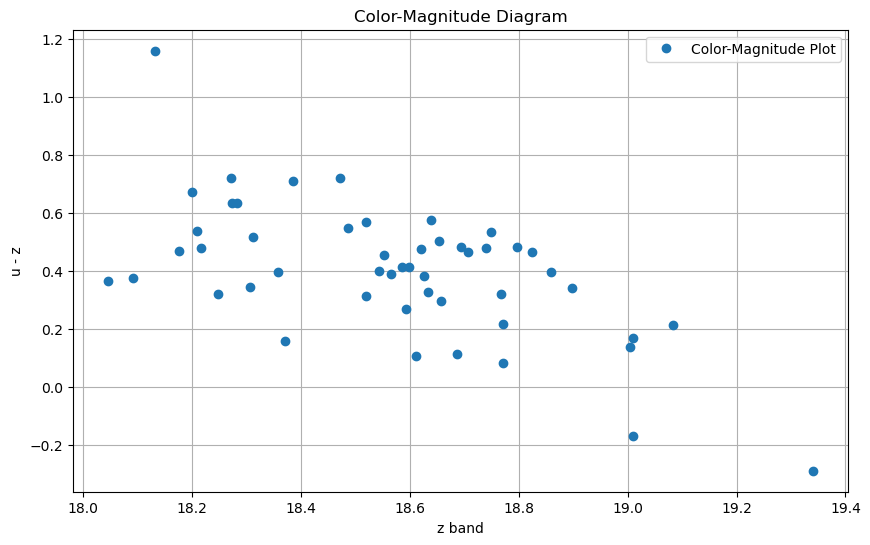

In [62]:

### Write your code here

# Open the FITS file
file_path = 'HW1/50 objects catalog.fits'
hdul = fits.open(file_path)
u = hdul[1].data['SDSS_u']
z = hdul[1].data['SDSS_z']

# Create a color-magnitude plot
plt.figure(figsize=(10, 6))
plt.plot(z, u - z, 'o', label='Color-Magnitude Plot')
plt.xlabel('z band')
plt.ylabel('u - z')
plt.title('Color-Magnitude Diagram')
plt.legend()
plt.grid()
plt.show()

# Close the FITS file
hdul.close()







3-5 sentences for each question.


b). What are their photometric properties (based on the SDSS images)? (Are they extended or point sources? Are they blue or red?) (5%)

Most of the objects are blue and they look like the point sources in the SDSS images. The images do not reveal any clear structure, making it difficult to identify the obj are stars or QSOs based on photometry. Since both stars and quasars can appear as point sources and blue in color, only use photometric data is not a good way to check their class


c). What can you see from their spectra? (Are there any emission lines and/or continuum?)  (5%)

The spectra of these objects show multiple emission lines such as CIV, CIII, CII, Mg, OII, and OIII. These strong emission lines also have different widths, asymmetries may due to velocity shift, suggest they are active objects, as stars usually present the absorption lines due to elements in their atmospheres absorbing specific wavelengths of light. The emission lines in these sources indicates they are likely not stars but rather active objects, such as quasars(Active galatic Nuclei).



d). What kind of sources are we looking at? (stars, quasars, or galaxies) What are the evidence supporting your conclusion? (10%)

I think these sources are most likely quasars. Quasars have hot accretion disks that make strong emission lines in their spectra. becuase of most of these source are not blocked by the dust, it allows us to detect these lines. Additionally, quasars are known to emit strongly in the UV and X-ray band,  the spectra also show higher redshift compare to normal star, this is also the reason why these objects are blue. Based on the spectral evidence, redshift and photometry, it is reasonable to conclude that these sources are quasars.


e). Do you find any interesting or unexpected objects? Download the spectra of the interesting / unexpected objects and plot it. (10%)

Describe why you think they are interesting. (hints: check the outliers in the color-magnitude plot from Question a) 


Object 18 has a z-band magnitude greater than 19
Object 20 has a negative u - z color
Object 20 has a z-band magnitude greater than 19
Object 25 has a z-band magnitude greater than 19
Object 40 has a z-band magnitude greater than 19
Object 48 has a negative u - z color
Object 48 has a z-band magnitude greater than 19


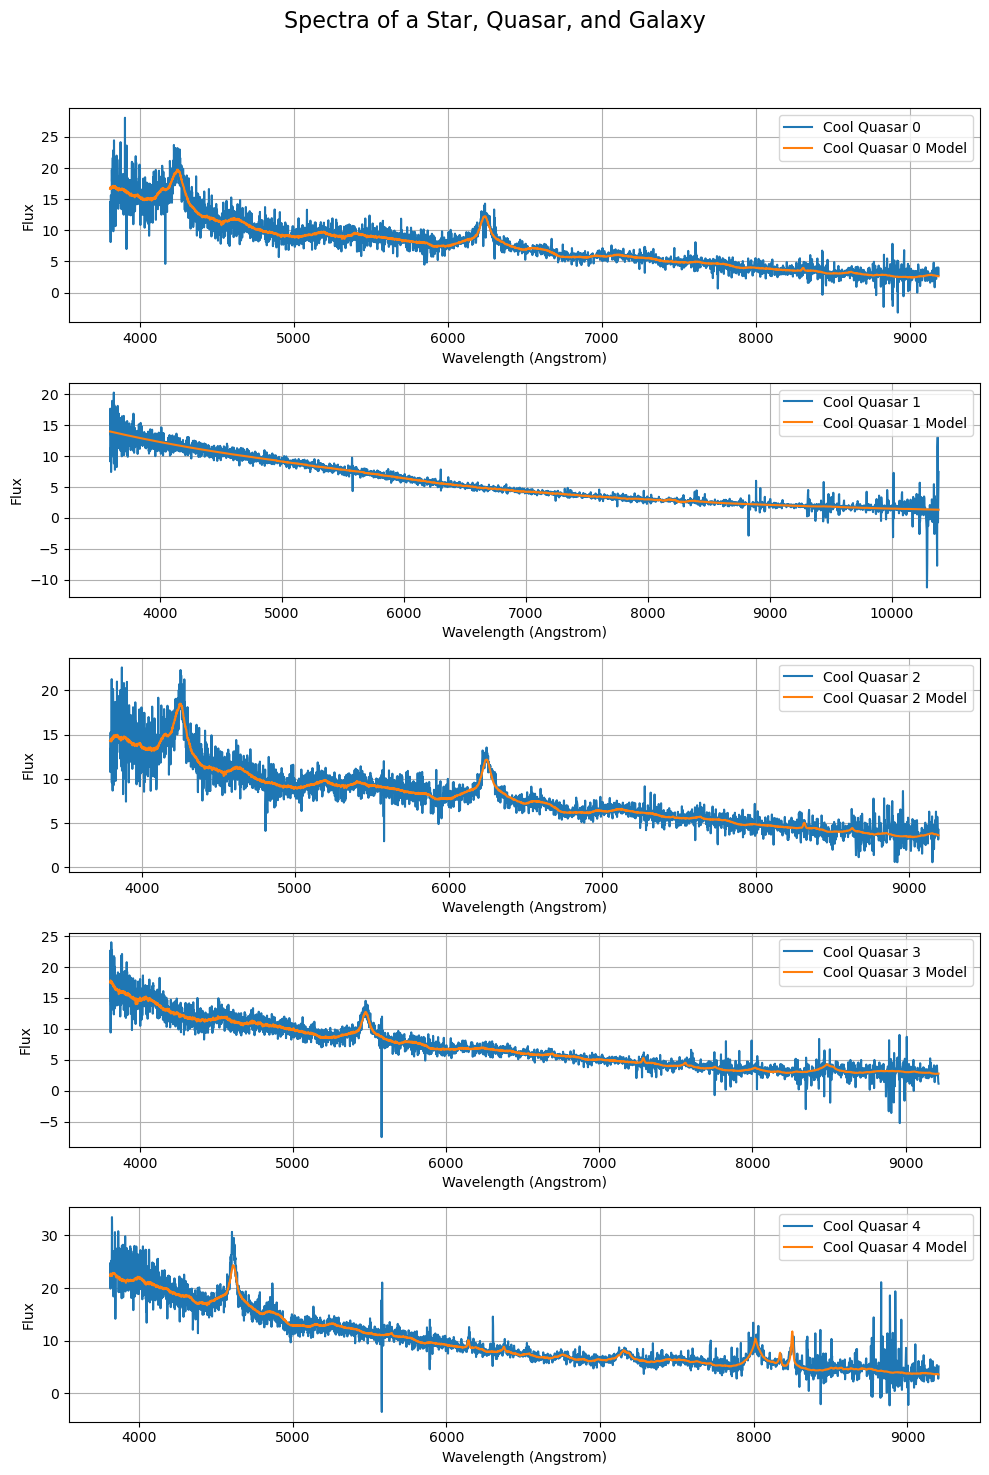

In [63]:
### Write your code here

#Check the interest QSOs
for i in range(len(u)):
    if u[i] - z[i] < 0:
        print('Object', i, 'has a negative u - z color')
    if z[i] > 19: 
        print('Object', i, 'has a z-band magnitude greater than 19')

# Function to download and plot SDSS spectrum
def download_and_plot_spectrum(ax, path, label):
    hdul = fits.open(path)

    flux = hdul[1].data['flux']
    model = hdul[1].data['model']
    loglam = hdul[1].data['loglam']
    wavelength = 10**loglam  # Convert to wavelength from log scale

    # Plot the spectrum on the provided axis (ax)
    ax.plot(wavelength, flux, label=label)
    ax.plot(wavelength, model, label=f'{label} Model')
    ax.set_xlabel('Wavelength (Angstrom)')
    ax.set_ylabel('Flux')
    ax.legend()
    ax.grid(True)


# Create a figure with 5 subplots
fig, axs = plt.subplots(5, 1, figsize=(10, 15))  

# plot spectra for each object 
for i in range(5):
    QSO_path = f"HW1/Cool_QSO_{i}.fits"
    download_and_plot_spectrum(axs[i], QSO_path, label=f'Cool Quasar {i}')


# Show the plot
plt.suptitle('Spectra of a Star, Quasar, and Galaxy', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


I used two criteria to identify interesting QSOs:

- u - z < 0
- z-band magnitude < 19

The criteria identified two objects. I expected to find red objects, but the photometry also show the blue objects. Then I found the Previous studies (e.g., Peth et al., 2010) have shown that high-redshift quasars tend to appear bluer in optical-NIR colors than models predict. 

However, the redshifts of these objects are higher than others in the sample. The first source has a redshift of z ~ 1.23, and its spectrum shows absorption lines such as K, H, and CaII, likely caused by dust absorption. The second source has a redshift of z ~ 5.77. Its spectrum reveals significant Ly-ɑ  emission, with most other lines redshifted out of the observed range.

I also compared these with sources that only satisfy the second criterion. These objects show similar features, indicating that dust may be causing their mag larger, making them appear fainter.

## 3. Identifying high-redshift quasars (z>5.5) from the SDSS catalog

(25%)

1. Open the quasar catalog (https://www.dropbox.com/scl/fi/risptvbtc9bek883qhj07/DR16Q_v4.fits?rlkey=1nhi88u1i8uyy0mrisbf7fhvl&dl=0),
2. Find the information about redshifts, 
3. Select quasars with redshifts>5.5, 
4. Check the sources on the imaging tool, 
5. Check the spectra of the quasars. 

The above are what we learned from the class. Use what we learn to address the following questions. 


Please answer the following questions:

a). Please use "Z" column to select redshift>5.5 quasars. How many sources satisfy this condition? [5%]

[total of 438 sources.]

b). Select 10 sources (with Z>5.5) and find their images and spectra from the SDSS imaging server. [5%]
- Based on the images, what are their colors? blue or red?

[the first and eighth appear red, the others look white or blue. However, due to most of the sources are faint, it is difficult to identify their colors based on imaging .

the image show at the code part, the ten counting from the front.]


c). We now use a different redshift estimation. Use "Z_QN" column to select redshift>5.5 quasars. How many sources satisfy this condition? [5%]

[only 2 sources.]

d). Select 10 sources (with Z_QN>5.5) and find their images and spectra from the SDSS imaging server. [5%]
- Based on the images, what are their colors? blue or red?


- The first quasar is too faint to discern its color properly, while the second appears red.
- The spectra for these objects show the features of QSOs, such as strong emission lines and Ly- alpha. These spectra are shown in the code, the last two.


e). Is there any differences between the quasars selected with Z_QN and Z? If so, what are the reasons for these differences? [5%]

Althrough the "Z" and "Z_QN" columns are redshift, there are some differences. The "Z" column  show “primary” redshift for each object (Lyke, et al., 2020), but in this case, the sources include objects with redshifts around ~1.3, indicating that the redshift in this case may have been influenced by some reason such as the broad emission lines in quasars, which can make significant errors in redshift estimates.

Objects selected with "Z_QN" show significant Ly- alpha emission lines, indicating that they are truly high-redshift (z > 5.5) quasars . The PCA and QuasarNET redshifts are included in their own columns in DR16Q but were not used to inform the Z column. (Lyke, et al., 2020). The "Z_QN" values are more accurate for quasars by QuasarNETm (Busca & Balland 2018). As these researchs, "Z_QN" is a better method for estimating redshift in quasars.





Number of quasars with Z > 5.5: 438
Number of quasars with Z_QN > 5.5: 2


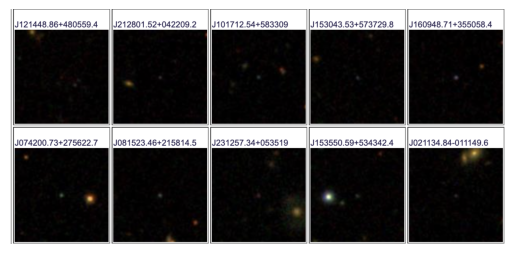

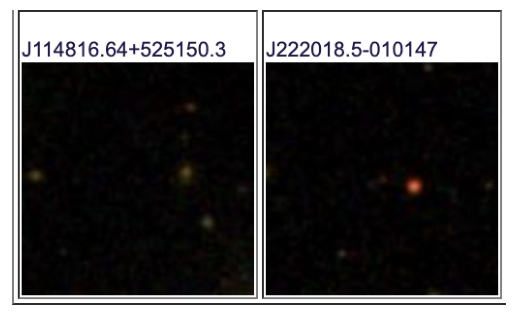

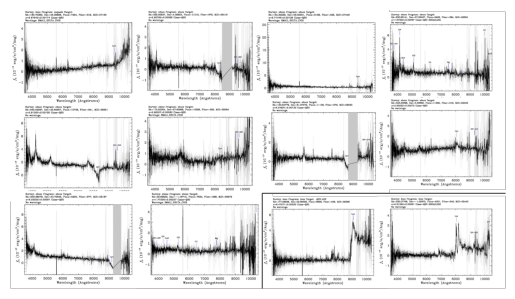

In [56]:
### Write your code here 

import numpy as np
import pandas as pd
import matplotlib.image as mpimg

# Load the FITS file 
fits_file = "HW1/DR16Q_v4.fits"  

# Open the FITS file
with fits.open(fits_file) as hdul:
    quasar_data = hdul[1].data

# Filter quasars with redshift Z > 5.5
high_z_quasars = quasar_data[quasar_data['Z'] > 5.5]

# Print the number of quasars with Z > 5.5
num_high_z_quasars = len(high_z_quasars)
print(f"Number of quasars with Z > 5.5: {num_high_z_quasars}")
# Select 10 quasars from high-z group
selected_quasars = np.random.choice(high_z_quasars, size=10, replace=False)

ra = selected_quasars['RA']
dec = selected_quasars['DEC']   


# Filter quasars with Z_QN > 5.5
high_z_qn_quasars = quasar_data[quasar_data['Z_QN'] > 5.5]

# Print the number of quasars with Z_QN > 5.5
num_high_z_qn_quasars = len(high_z_qn_quasars)
print(f"Number of quasars with Z_QN > 5.5: {num_high_z_qn_quasars}")

# Select 10 quasars from high-z_qn group
if num_high_z_qn_quasars < 10:
    selected_qn_quasars = high_z_qn_quasars
else:
    selected_qn_quasars = np.random.choice(high_z_qn_quasars, size=10, replace=False)

ra_qn = selected_qn_quasars['RA']
dec_qn = selected_qn_quasars['DEC']

# create a pd.DataFrame for the selected quasars
data = {'RA': ra, 'DEC': dec}
data_qn = {'RA': ra_qn, 'DEC': dec_qn}
df = pd.DataFrame(data)
df_qn = pd.DataFrame(data_qn)   
merge_df = pd.concat([df, df_qn], ignore_index=True)

merge_df.to_csv('HW1/selected_quasars.csv', index=False)

# show the image
image_path = 'HW1/z_selected.png'
image_path1 = 'HW1/z_QN.png'
image_path2 = 'HW1/spectra_12.png'
image = Image.open(image_path)
image1 = Image.open(image_path1)
image2 = Image.open(image_path2)

# Read the image using matplotlib
img = mpimg.imread(image_path)
img1 = mpimg.imread(image_path1)
img2 = mpimg.imread(image_path2)

# Display the image 
plt.imshow(img)
plt.axis('off')  
plt.show()
plt.imshow(img1)
plt.axis('off')  
plt.show()
plt.imshow(img2)
plt.axis('off')  
plt.show()


                            

## 4. Read Gunn (2020) https://ui.adsabs.harvard.edu/abs/2020ARA%26A..58....1G/abstract and answer the following questions:
## Please describe with your own words. (Note that direct copy and paste from the article is plagiarism.)

(20%)

3-5 sentences for each question.

a). What makes SDSS so transformative according to Gunn? (5%)
[Describe] 

 The SDSS obtained the open data and open tool, which provided astronomers with access to a large and detailed dataset, everyone or groups can use this data to do anything which they want to study. This policy boosted collaboration and led to a lot of different studies. not just like the traditional model of small, exclusive research groups. this is why Gunn, 2020 said: "the SDSS has produced 9299 scientific papers, which have been cited half a million times."


b). What are the unexpected key science results offered by SDSS? (5%)
[Describe]

SDSS found some unexpected object or phenomenon like detecting weak lensing, brown dwarf and high-redshift quasar. At first, Astronomer didn’t think SDSS could detect weak lensing, but it proved to be more precise than expected. The brown dwarf usually to use IR observation to study, but the wide FOV let SDSS can find these objects more easily.  SDSS also identified the high-redshift quasars, provided insights into the early Universe.

SDSS also found the BAO results, asteroid population, large-scale structure and many stellar tidal event. These scientific result aren't expected either.



c). What did you learn after reading this article? (5%)
[Describe]

The article shows how new technology and openess policy transformed astronomy field, it increased the large-scale collaborations. the advanced technology and computing power will help us to push the research progress. However, Gunn emphasizes the  open data policies made it possible for scientists around the world to work together and push the field forwar, the best example is SDSS. International, open and democratic will help the region better.



d). What happened to the Hubble Space Telescope when it was just launched? [You might also need to google it.] (5%)
[Describe]

The Hubble Space Telescope was found to have a flaw in its primary mirror, resulting in blurry images. It is because the mirror had been polished incorrectly due to a mistake with a testing lens. NASA fixed this issue by sending astronauts on a space shuttle(STS-61) mission to install corrective optics at 1993. 

